# Setup

In [1]:
from cause_identification import Metrics, CausalObservation, Granularity
from flocking import Scenarii
from utils import get_3_axes
from experiments import load_scms

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
import numpy as np, matplotlib.pyplot as plt
from collections import Counter

# Utils

In [ ]:
# def filter_causes_percentile(scores, k):
#     id_sets = []
#     for i in range(3):
#         valid_ids = get_percentile(scores[i], k)
#         id_sets.append(set(valid_ids))
#     return np.array(list(set.intersection(*id_sets)))

In [43]:
# def filter_causes(scores, N):
#     for i in range(100):
#         ids = filter_causes_percentile(scores, i)
#         if len(ids) > N:
#             print(f"Data select from top {i}%")
#             break
#     ids = sorted(ids, key=lambda i: np.prod(scores[:,i]))[:N]
#     return ids

In [44]:
# def get_percentile(score, k):
#     threshold = np.percentile(score, k)
#     return np.argwhere(score <= threshold).flatten()

In [45]:
# def plot_score_distibution(scores, metrics, round_x=True, hist_cost=True):
#     axes = get_3_axes(sharey=True)
#     axes[0].set_yscale('log')
#     if hist_cost:
#         axes[0].hist(scores[0], bins=100)
#         ids = (1,2)
#     else:
#         ids = (0,1,2)
    
#     for i in ids:
#         counter = Counter(scores[i])
#         X, Y = zip(*counter.items())
#         ids = np.argsort(X)
#         if round_x:
#             axes[i].bar([str(round(X[i])) for i in ids], [Y[i] for i in ids])
#         else:
#             axes[i].bar([str(round(X[i],2)) for i in ids], [Y[i] for i in ids])
#             axes[i].tick_params('x', rotation=45)
#     for i in range(3):
#         axes[i].set_title(metrics[i])
#     plt.suptitle("Metric distribution over the 5 SCMs")
#     plt.tight_layout()
#     plt.show()

In [46]:
# def sort_causes_weights(scores, weights):
#     w = np.array([weights[m] for m in Metrics]).reshape(-1,1)
#     scores = np.sum(scores / scores.max(axis=1, keepdims=True) * w, axis=0)
#     return np.argsort(scores)

# Main

In [22]:
metrics = [m.value for m in Metrics]

## Data gathering

In [23]:
def get_states(scenario, prefix):
    scms = load_scms(scenario)
    run = scms[0].actual_run
    hp = scms[0].hp
    first_hit = get_first_hit(run, hp)
    axes = get_3_axes()
    show_boids(run[0], hp, ax=axes[0], title="Initial state")
    show_boids(run[first_hit], hp, ax=axes[1], title="Time of collision")
    show_boids(run[-1], hp, ax=axes[2], title="Final state")
    plt.tight_layout()
    plt.savefig(prefix+f"results/states_{scenario.value}.pdf")

In [24]:
v2l = {
    CausalObservation.BOOLEAN: "Bool.", 
    CausalObservation.PARAMS: "Param.", 
    CausalObservation.VARS: "Var."
}
a2l = {
    Granularity.BOID: "Agent",
    Granularity.FLOCK: "Flock"
}

def scm_label(scm):
    return "-".join([
            a2l[scm.entity_type], v2l[scm.obs_type]
        ])

In [25]:
def render_cost_distributions(prefix="../"):
    axes = get_3_axes()
    
    for ax, scenario in zip(axes, (Scenarii.ONE_FLOCK, Scenarii.FUSION, Scenarii.FREE)):
        causes, scores, scm_refs, scms = get_causes_scenario(scenario) 
        ax.set_title(scenario.value)
        ax.boxplot(
            [scm.scores[Metrics.COST.value] for scm in scms], 
            vert=True, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            medianprops=dict(color="red")
        )
        
        ax.set_xticks(range(len(scms)), [scm_label(scm) for scm in scms])
        ax.tick_params('x', rotation=45)
    axes[0].set_ylabel("Intervention cost")
    plt.tight_layout()
    plt.savefig(prefix+"results/cost_distributions.pdf")
    plt.show()

In [26]:
def render_distributions(metric, prefix="../"):
    if metric == Metrics.COMPLEXITY:
        legend_title = 'Cause length'
        save_name = "length"
        values = np.arange(1,5)
    else:
        legend_title = 'Time to collision'
        save_name = 'oldness'
        values = None
    axes = get_3_axes(sharey=True)
    for ax, scenario in zip(axes, (Scenarii.ONE_FLOCK, Scenarii.FUSION, Scenarii.FREE)):
        causes, scores, scm_refs, scms = get_causes_scenario(scenario) 
        if metric == Metrics.OLDNESS:
            scm = scms[0]
            first_hit = get_first_hit(scm.actual_run, scm.hp)
            steps = scm.get_intervention_steps()
            values = first_hit - steps
        ax.set_title(scenario.value)
        bars = np.zeros((len(values),5))
        # bars = [[] for i in range(4)]
        x_ticks = []
        for i, scm in enumerate(scms):
            x_ticks.append(scm_label(scm))
            counter = Counter(scm.scores[metric.value])
            for j, value in enumerate(values):
                n = counter[value]
                bars[j, i] = n
        bar_width = 0.8 / len(values)
        index = np.arange(len(x_ticks))
        for i, bars_i in enumerate(bars):
            ax.bar(index + i*bar_width, bars_i, bar_width, label=values[i])#f'Cause size={i+1}')
        ax.set_xticks(index, x_ticks)
        ax.tick_params("x", rotation=45)
        ax.set_yscale("log")
        ax.legend(title=legend_title, ncol=2, fontsize=7, title_fontsize=9)
    axes[0].set_ylabel("#causes")
    plt.tight_layout()
    plt.savefig(prefix+f"results/{save_name}_distribution.pdf")
    plt.show()

In [27]:
def get_n_causes():
    data = []
    columns = []
    index = []
    for ax, scenario in zip(axes, (Scenarii.ONE_FLOCK, Scenarii.FUSION, Scenarii.FREE)):
        data.append([])
        index.append(scenario.value)
        causes, scores, scm_refs, scms = get_causes_scenario(scenario)
        for scm in scms:
            data[-1].append(len(scm.causes))
            columns.append(scm.__class__.__name__)
    return pd.DataFrame(data, index=index, columns=columns[:5])

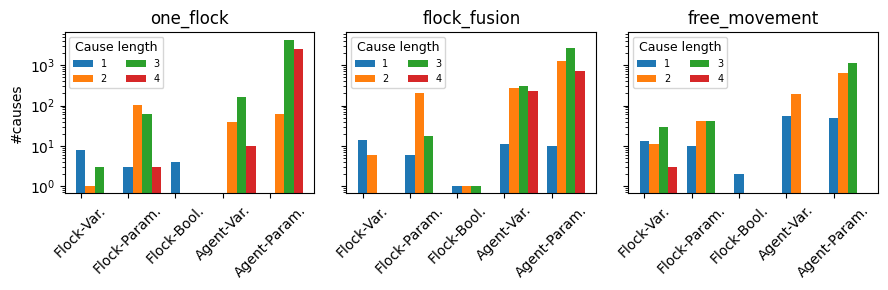

In [29]:
render_distributions(Metrics.COMPLEXITY)

In [30]:
# render_distributions(Metrics.OLDNESS)

In [31]:
# render_cost_distributions()

In [32]:
# get_n_causes()

In [33]:
# for scenario in Scenarii:
#     get_states(scenario, "../")

## Free Movement

In [34]:
# show_results(Scenarii.FREE, show_sim=True, show_distr=True, 
#                  show_distr_2D=True)

In [35]:
metrics

['Cost', 'Oldness', 'Complexity']

In [36]:
priorities = [(0,1,2), (1,0,2), (2,0,1)]
show_results(Scenarii.FREE, show_priorities=priorities)

Priotities: Cost Oldness Complexity
boid_11_x_30=132.92 -> score=[0.02, 5.0, 1.0]
boid_16_x_30=125.00 -> score=[0.09, 5.0, 2.0]
boid_4_x_30=123.56 & boid_39_x_30=107.67 -> score=[0.08, 5.0, 2.0]
boid_39_x_30=107.67 & boid_4_y_30=117.85 -> score=[0.08, 5.0, 2.0]
boid_4_y_33=114.22 & boid_39_x_30=107.67 -> score=[0.12, 5.0, 2.0]

Priotities: Oldness Cost Complexity
flock_17_x_34=116.03 -> score=[1.0, 0.8, 1.0]
flock_17_y_34=105.15 -> score=[1.0, 0.8, 1.0]
boid_16_y_34=98.04 & boid_4_angle_34=3.51 -> score=[1.0, 0.64, 2.0]
boid_16_x_34=113.95 & boid_4_angle_34=3.51 -> score=[1.0, 0.64, 2.0]
boid_16_angle_34=3.52 & boid_4_angle_34=3.51 -> score=[1.0, 0.88, 2.0]

Priotities: Complexity Cost Oldness
boid_11_x_30=132.92 -> score=[1.0, 0.02, 5.0]
boid_11_x_21=157.71 -> score=[1.0, 0.07, 14.0]
boid_11_y_21=118.69 -> score=[1.0, 0.07, 14.0]
boid_39_x_21=131.32 -> score=[1.0, 0.07, 14.0]
boid_16_x_0=157.20 -> score=[1.0, 0.07, 35.0]



## One flock

In [37]:
# show_results(Scenarii.ONE_FLOCK, show_sim=True, show_distr=True, 
#                  show_distr_2D=True)

In [38]:
priorities = [(0,1,2), (1,0,2), (2,0,1)]
show_results(Scenarii.ONE_FLOCK, show_priorities=priorities)#, show_priorities_graphic=True)

Priotities: Cost Oldness Complexity
boid_1_x_0=95.58 & boid_17_angle_0=4.88 -> score=[0.28, 15.0, 2.0]
boid_14_x_0=113.60 & boid_17_angle_0=4.88 -> score=[0.22, 15.0, 2.0]
boid_30_x_0=109.54 & boid_17_angle_0=4.88 -> score=[0.23, 15.0, 2.0]
boid_1_y_0=132.08 & boid_17_angle_0=4.88 -> score=[0.22, 15.0, 2.0]
boid_7_x_14=89.03 & boid_17_angle_0=4.88 -> score=[0.23, 15.0, 2.0]

Priotities: Oldness Cost Complexity
flock_3_x_14=104.76 -> score=[1.0, 8.24, 1.0]
flock_3_angle_14=4.77 -> score=[1.0, 22.26, 1.0]
flock_3_step_14=2.00 -> score=[1.0, 49.43, 1.0]
flock_5_x_12=104.44 -> score=[3.0, 7.98, 1.0]
flock_3_y_14=83.20 & flock_5_y_12=89.86 -> score=[3.0, 8.24, 2.0]

Priotities: Complexity Cost Oldness
flock_3_step_8=2.00 -> score=[1.0, 2.44, 7.0]
flock_3_x_14=104.76 -> score=[1.0, 8.24, 1.0]
flock_5_x_12=104.44 -> score=[1.0, 7.98, 3.0]
flock_3_x_8=103.83 -> score=[1.0, 8.24, 7.0]
flock_3_x_0=102.18 -> score=[1.0, 8.24, 15.0]



## Flock Fusion

In [42]:
show_results(Scenarii.FUSION, show_sim=True, show_distr=True, 
                show_distr_2D=True)

NameError: name 'show_simulation' is not defined

In [40]:
priorities = [(0,1,2), (1,0,2), (2,0,1)]
show_results(Scenarii.FUSION, show_priorities=priorities)#, show_priorities_graphic=True)

Priotities: Cost Oldness Complexity
boid_12_y_0=159.64 & boid_2_y_0=175.51 -> score=[0.04, 29.0, 2.0]
boid_9_x_0=79.61 -> score=[0.02, 29.0, 2.0]
boid_4_y_17=110.98 & boid_11_x_17=72.62 -> score=[0.08, 12.0, 2.0]
boid_1_x_0=61.46 -> score=[0.09, 29.0, 2.0]
boid_12_x_0=23.15 & boid_2_y_0=175.51 -> score=[0.09, 29.0, 2.0]

Priotities: Oldness Cost Complexity
boid_10_angle_28=4.74 & boid_3_x_28=81.35 -> score=[1.0, 0.28, 2.0]
boid_10_y_28=56.91 & boid_3_angle_28=4.93 -> score=[1.0, 0.64, 2.0]
boid_10_angle_28=4.74 & boid_3_y_28=65.51 -> score=[1.0, 0.72, 2.0]
boid_10_angle_28=4.74 & boid_11_angle_28=4.78 -> score=[1.0, 0.88, 2.0]
boid_7_angle_28=4.64 & boid_10_angle_28=4.74 & boid_1_x_28=72.72 -> score=[1.0, 0.82, 3.0]

Priotities: Complexity Cost Oldness
boid_9_angle_0=4.71 -> score=[1.0, 0.16, 29.0]
boid_11_angle_0=4.71 -> score=[1.0, 0.16, 29.0]
boid_7_x_0=69.43 -> score=[1.0, 0.27, 29.0]
boid_8_x_0=71.91 -> score=[1.0, 0.27, 29.0]
boid_8_max_speed_0=4.00 -> score=[1.0, 0.38, 29.0]

